# Sistema de desenho na tela

- Construir um sistema que possibilite ao usuário desenhar na tela em tempo real
- O usuário segura um objeto específico na frente da câmera, e o movimento do objeto cria uma trajetória que é desenhada na tela
- Considerar dois objetos diferentes, que desenham em cores distintas
- Pode ser utilizada uma dessas duas estratégias para ambos os objetos: 
    1. Objetos com cores muito distintas do resto da cena (ex: uma bola de tênis nova). Nesse caso, os objetos são identificados usando limiarização de cores
    2. Objetos com padrões específicos (ex: qr code ou chaveiro). Nesse caso, os objetos são identificados usando casamento de template (template matching)
- Não utilizar detecção de ponto-chave (YOLO, MediaPipe, etc)

## Códigos de exemplo

Padrão de classe a ser utilizada para fazer o desenho. A interface da classe é baseada na class FrameProcessor vista em aula.

In [1]:
from camera_painter import CameraPainter

camera_painter = CameraPainter(canvas_size = (768, 910))

Exemplo artifical de captura de quadros:

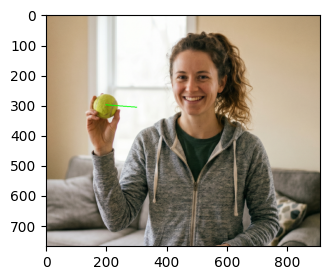

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Duas imagens exemplificando dois quadros de um vídeo
img1 = np.array(Image.open("ball1.png"))
coords1 = (306, 301)
img2 = np.array(Image.open("ball2.png"))
coords2 = (298, 198)

EXAMPLE_FRAMES = [img1, img2]
EXAMPLE_COORDS = iter([coords1, coords2])
# Substitui a função de detecção de objetos do CameraPainter por uma função de exemplo que retorna 
# as coordenadas pré-definidas. REMOVER ISSO PARA O PROJETO REAL.
camera_painter.detect_object = lambda frame: next(EXAMPLE_COORDS)

class MockVideoStream:
    """Simula a classe VideoStream construída em aula. No projeto real, a classe a ser usada
    é a VideoStream, que captura os quadros da webcam."""

    def start(self, processor):
        # Simula a captura de quadros da webcam usando duas imagens de exemplo.
        for frame in EXAMPLE_FRAMES:
            display_img = processor.process_frame(frame)
            # Exibe display_img na tela usando cv2.imshow
            #...
            # Exemplo usando matplotlib, que não é adequado para vídeos, mas serve para ilustrar a ideia
            plt.imshow(display_img)

video_streeam = MockVideoStream()
video_streeam.start(camera_painter)